<a href="https://colab.research.google.com/github/revathikrishapk/titanic-survival-prediction-mlp/blob/main/Team_Lambda_Titanic_Classification_Revathi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction Using Machine Learning and Neural Networks

Importing dependencies


In [1]:
#data handling
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#model evaluation
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

#reproductibility
import random


Setting random seeds for reproductibility

In [2]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

Dataset Loading

In [3]:
df=pd.read_csv('/content/Titanic-Dataset.csv')


Information about the dataset

In [4]:
print("\nfirst 5 rows:",df.head())
print("\ndataset shape:",df.shape)
print("\nname of columns:",df.columns.tolist())
print("\ndata type:",df.dtypes)



first 5 rows:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

Checking for missing values

In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

print(missing_info[missing_info["Missing Values"] > 0])

          Missing Values  Missing Percentage
Age                  177           19.865320
Cabin                687           77.104377
Embarked               2            0.224467


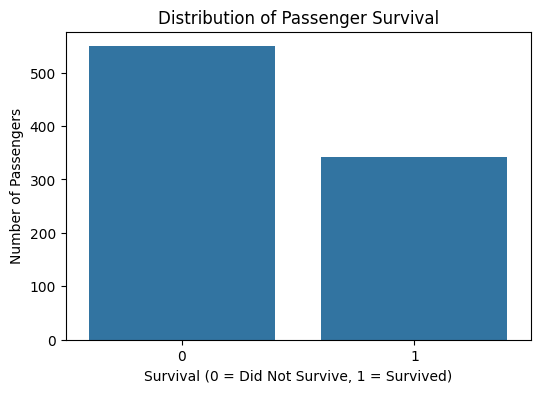

In [28]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Distribution of Passenger Survival")
plt.xlabel("Survival (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.show()

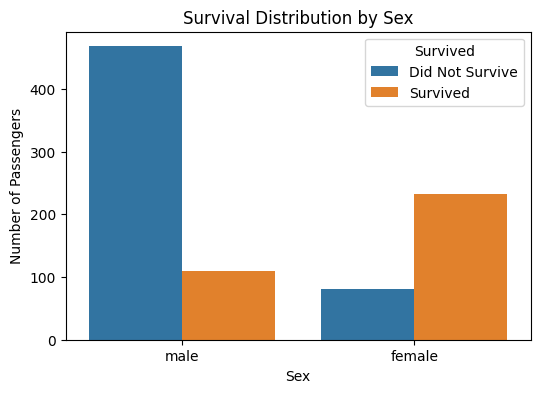

In [29]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(
    title="Survived",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

Handling missing values

In [6]:
# fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it has too many missing values
df = df.drop(columns=["Cabin"])

# Verify that missing values have been handled
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Feature Selection

In [7]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

target = "Survived"
X = df[features]
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features shape: (891, 7)
Target shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


Why these features?
Pclass - Passenger's socioeconomic/travel class
Sex - Likely important for survival
Age - Children and adults may have had different survival chances
SibSp - Number of siblings/spouses aboard
Parch - Number of parents/children aboard
Fare - Can indirectly reflect passenger class and socioeconomic status
Embarked - Port of embarkation may capture differences in passenger groups

Why are we not using these?

PassengerId - Just an identifier; it has no meaningful relationship with survival.
Name - Raw text and high-cardinality; we can later engineer a feature like Title from it as an MSc-level enhancement.
Ticket - High-cardinality categorical feature and requires additional feature engineering.
Cabin - Already dropped due to 77.1% missing values.


Encode Categorical Features

In [8]:
# Define categorical and numerical features

categorical_features = ["Sex", "Embarked"]

numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]
# Create preprocessing transformers

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

numerical_transformer = StandardScaler()
# Combine preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Data splitting

In [9]:
# Split data into training (70%), validation (15%), and test (15%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (623, 7)
Validation set: (134, 7)
Test set: (134, 7)


Fit the Preprocessor on Training Data Only

In [10]:
# Fit the preprocessor only on the training data

X_train_processed = preprocessor.fit_transform(X_train)

# Use the learned transformations to transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Check the shapes
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (623, 8)
Processed validation shape: (134, 8)
Processed test shape: (134, 8)


Baseline Model - Train Logistic Regression

In [11]:
# Baseline Model: Logistic Regression

log_reg = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

log_reg.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Evaluating the Logistic Regression Baseline on the Validation Set

In [12]:
# Make predictions on the validation set

y_val_pred_log = log_reg.predict(X_val_processed)

# Calculate evaluation metrics

log_val_accuracy = accuracy_score(y_val, y_val_pred_log)
log_val_precision = precision_score(y_val, y_val_pred_log)
log_val_recall = recall_score(y_val, y_val_pred_log)
log_val_f1 = f1_score(y_val, y_val_pred_log)

print("Logistic Regression - Validation Results")
print(f"Accuracy:  {log_val_accuracy:.4f}")
print(f"Precision: {log_val_precision:.4f}")
print(f"Recall:    {log_val_recall:.4f}")
print(f"F1 Score:  {log_val_f1:.4f}")

Logistic Regression - Validation Results
Accuracy:  0.8582
Precision: 0.8511
Recall:    0.7692
F1 Score:  0.8081


Logistic Regression Confusion Matrix

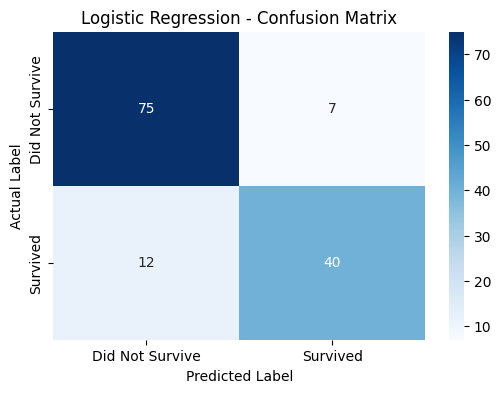

In [13]:
# Confusion Matrix for Logistic Regression

cm_log = confusion_matrix(y_val, y_val_pred_log)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Build Neural Network Model

In [14]:
mlp_model = keras.Sequential([

    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(32, activation="relu"),

    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

# Display the model architecture
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Compiling Neural Network

In [15]:
mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Training Neural Network

In [16]:
# Define Early Stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train the Neural Network

history = mlp_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6806 - loss: 0.6086 - val_accuracy: 0.6866 - val_loss: 0.5803
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7528 - loss: 0.5638 - val_accuracy: 0.7537 - val_loss: 0.5387
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7624 - loss: 0.5295 - val_accuracy: 0.7836 - val_loss: 0.5055
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7721 - loss: 0.5026 - val_accuracy: 0.8284 - val_loss: 0.4806
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7865 - loss: 0.4817 - val_accuracy: 0.8284 - val_loss: 0.4618
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7961 - loss: 0.4647 - val_accuracy: 0.8284 - val_loss: 0.4463
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8058 - loss: 0.4503 - val_accuracy: 0.8358 - val_loss: 0.4326
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8058 - loss: 0.4384 - val_accuracy: 0.8507 - 

Evaluate MLP on the validation set

In [17]:
# Predict survival probabilities on the validation set

y_val_prob_mlp = mlp_model.predict(X_val_processed)

# Convert probabilities into binary predictions
y_val_pred_mlp = (y_val_prob_mlp >= 0.5).astype(int).flatten()

# Calculate evaluation metrics

mlp_val_accuracy = accuracy_score(y_val, y_val_pred_mlp)
mlp_val_precision = precision_score(y_val, y_val_pred_mlp)
mlp_val_recall = recall_score(y_val, y_val_pred_mlp)
mlp_val_f1 = f1_score(y_val, y_val_pred_mlp)

print("MLP Neural Network - Validation Results")
print(f"Accuracy:  {mlp_val_accuracy:.4f}")
print(f"Precision: {mlp_val_precision:.4f}")
print(f"Recall:    {mlp_val_recall:.4f}")
print(f"F1 Score:  {mlp_val_f1:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MLP Neural Network - Validation Results
Accuracy:  0.8731
Precision: 0.9268
Recall:    0.7308
F1 Score:  0.8172


Compare Logistic Regression and MLP on the validation set


In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP Neural Network"],
    "Accuracy": [log_val_accuracy, mlp_val_accuracy],
    "Precision": [log_val_precision, mlp_val_precision],
    "Recall": [log_val_recall, mlp_val_recall],
    "F1 Score": [log_val_f1, mlp_val_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858209,0.851064,0.769231,0.808081
1,MLP Neural Network,0.873134,0.926829,0.730769,0.817204


Plot Training and Validation Curves

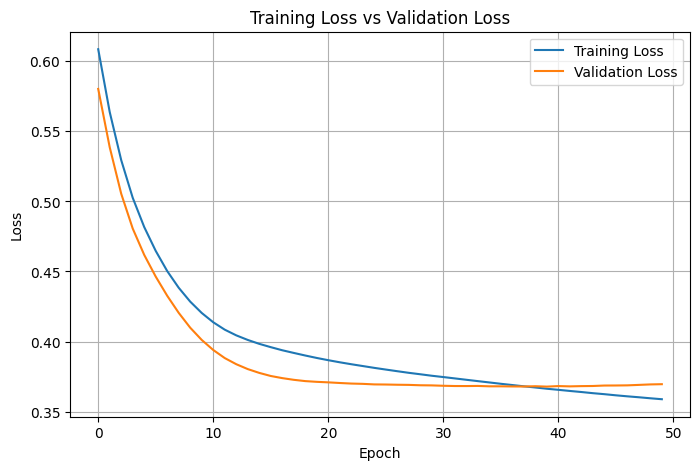

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

Plot Training and Validation Accuracy

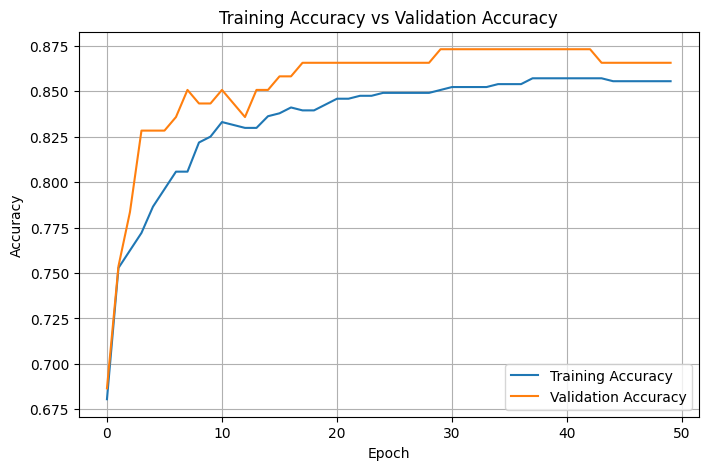

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

The model learned effectively, as both training and validation loss decreased significantly during training. The validation loss reached a plateau around the later epochs and showed only minor fluctuations, while the training and validation accuracy remained relatively close. Therefore, the model does not show signs of severe overfitting or underfitting. Early stopping helped prevent unnecessary training after validation performance stopped improving.

**Building Model drop out**

In [21]:
# Experiment: MLP with Dropout

dropout_model = keras.Sequential([

    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dropout_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Train Dropout Model

In [22]:
# Early stopping for the Dropout model

early_stopping_dropout = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train the Dropout model

history_dropout = dropout_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_dropout],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5024 - loss: 0.7120 - val_accuracy: 0.7090 - val_loss: 0.6686
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6806 - loss: 0.6415 - val_accuracy: 0.7537 - val_loss: 0.6082
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7239 - loss: 0.5859 - val_accuracy: 0.7463 - val_loss: 0.5741
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7480 - loss: 0.5551 - val_accuracy: 0.7537 - val_loss: 0.5501
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7335 - loss: 0.5360 - val_accuracy: 0.7687 - val_loss: 0.5303
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7303 - loss: 0.5338 - val_accuracy: 0.7910 - val_loss: 0.5138
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7496 - loss: 0.5180 - val_accuracy: 0.7836 - val_loss: 0.4986
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7448 - loss: 0.5015 - val_accuracy: 0.7910 - 

Evaluate dropout model

In [23]:
# Predict survival probabilities using the Dropout model

y_val_prob_dropout = dropout_model.predict(X_val_processed)

# Convert probabilities into binary predictions
y_val_pred_dropout = (y_val_prob_dropout >= 0.5).astype(int).flatten()

# Calculate evaluation metrics

dropout_val_accuracy = accuracy_score(y_val, y_val_pred_dropout)
dropout_val_precision = precision_score(y_val, y_val_pred_dropout)
dropout_val_recall = recall_score(y_val, y_val_pred_dropout)
dropout_val_f1 = f1_score(y_val, y_val_pred_dropout)

print("MLP with Dropout - Validation Results")
print(f"Accuracy:  {dropout_val_accuracy:.4f}")
print(f"Precision: {dropout_val_precision:.4f}")
print(f"Recall:    {dropout_val_recall:.4f}")
print(f"F1 Score:  {dropout_val_f1:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MLP with Dropout - Validation Results
Accuracy:  0.8731
Precision: 0.9268
Recall:    0.7308
F1 Score:  0.8172


Final Validation Comparison Table

In [24]:
# Final validation comparison of all models

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Original MLP",
        "MLP with Dropout"
    ],
    "Accuracy": [
        log_val_accuracy,
        mlp_val_accuracy,
        dropout_val_accuracy
    ],
    "Precision": [
        log_val_precision,
        mlp_val_precision,
        dropout_val_precision
    ],
    "Recall": [
        log_val_recall,
        mlp_val_recall,
        dropout_val_recall
    ],
    "F1 Score": [
        log_val_f1,
        mlp_val_f1,
        dropout_val_f1
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858209,0.851064,0.769231,0.808081
1,Original MLP,0.873134,0.926829,0.730769,0.817204
2,MLP with Dropout,0.873134,0.926829,0.730769,0.817204


Final Evaluation on the Test Set

In [25]:
# Make predictions on the unseen test set

y_test_prob_mlp = mlp_model.predict(X_test_processed)

# Convert probabilities into binary predictions
y_test_pred_mlp = (y_test_prob_mlp >= 0.5).astype(int).flatten()

# Calculate final test metrics

test_accuracy = accuracy_score(y_test, y_test_pred_mlp)
test_precision = precision_score(y_test, y_test_pred_mlp)
test_recall = recall_score(y_test, y_test_pred_mlp)
test_f1 = f1_score(y_test, y_test_pred_mlp)

print("Final MLP - Test Set Results")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Final MLP - Test Set Results
Accuracy:  0.7836
Precision: 0.7750
Recall:    0.6078
F1 Score:  0.6813


Final Test Confusion Matrix

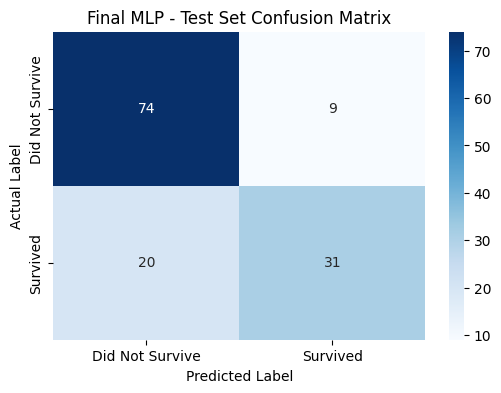

In [26]:
# Confusion Matrix for the final MLP on the test set

cm_test = confusion_matrix(y_test, y_test_pred_mlp)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final MLP - Test Set Confusion Matrix")

plt.show()

In [27]:
# Detailed classification report

print(classification_report(
    y_test,
    y_test_pred_mlp,
    target_names=["Did Not Survive", "Survived"]
))

                 precision    recall  f1-score   support

Did Not Survive       0.79      0.89      0.84        83
       Survived       0.78      0.61      0.68        51

       accuracy                           0.78       134
      macro avg       0.78      0.75      0.76       134
   weighted avg       0.78      0.78      0.78       134



## Final Conclusion

This project developed and evaluated a Feed Forward Neural Network (MLP) to predict passenger survival using the Titanic dataset.

The dataset was preprocessed by handling missing values, removing the Cabin feature due to its high percentage of missing data, encoding categorical variables, and scaling numerical features. The data was divided into training, validation, and test sets to ensure a fair evaluation.

A Logistic Regression model was first used as a baseline. The baseline achieved a validation accuracy of 85.82%. The MLP improved the validation accuracy to 87.31% and also achieved higher precision and F1-score. An additional experiment was conducted by adding Dropout layers, but this did not improve the validation metrics. Therefore, the simpler original MLP was selected as the final model.

On the unseen test set, the final MLP achieved an accuracy of 78.36%, precision of 77.50%, recall of 60.78%, and F1-score of 68.13%.

The difference between validation and test performance highlights the importance of evaluating machine learning models on completely unseen data. While the model demonstrated reasonable predictive performance, the lower recall for survivors and the presence of 20 false negatives indicate opportunities for improvement. Future work could include feature engineering, hyperparameter tuning, class weighting, and threshold optimization to improve generalization and survivor recall.